# Plataforma de Análisis Comparativo de Partituras — v2.0
### Musicología Computacional · Transformers · Modelos Dirichlet (LDA) · Matemáticas

Versión con **dos métodos de Machine Learning implementados de verdad y entrenados aquí mismo**:

1. **Transformer (self-attention)** — un *Transformer encoder* entrenado con objetivo
   *Masked Language Modeling* sobre la música tokenizada del corpus. Produce un *embedding*
   aprendido por obra. Arquitectura y entrenamiento reales en PyTorch.
2. **Dirichlet / LDA (Latent Dirichlet Allocation)** — modelado de tópicos: cada obra es
   un "documento" de palabras musicales, y LDA descubre **tópicos latentes** (vocabularios
   armónico-melódicos). Cada obra queda como una **distribución Dirichlet sobre tópicos**.

Además conserva el núcleo v1: características interpretables, métricas de similitud,
clustering, detección de motivos con resaltado sobre la partitura, y red de influencias.

> **Honestidad sobre la escala.** Con ~8 obras, el Transformer *demuestra* la arquitectura
> y el bucle de entrenamiento (la *loss* baja de verdad) pero no aprende estructura musical
> rica — eso exige un corpus grande o un *checkpoint* preentrenado. El LDA, en cambio,
> ya da tópicos interpretables con pocos datos. Ambas interfaces (`emb[obra]=vector`) están
> listas para escalar sin reescribir nada.


## 00 · Setup

In [ ]:
# En Colab descomenta:
# !pip install music21 scipy scikit-learn networkx matplotlib torch -q
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
from music21 import corpus, converter, note, chord
from scipy.spatial.distance import jensenshannon, cosine
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch, torch.nn as nn
np.random.seed(42); torch.manual_seed(42)
print('Entorno listo · torch', torch.__version__)

Entorno listo · torch 2.11.0+cpu


## 17 · Dataset (corpus integrado + tus archivos)

In [ ]:
CATALOG = {
 'Bach · BWV 66.6'   : dict(path='bach/bwv66.6',                 composer='J.S. Bach',    year=1724),
 'Bach · BWV 7.7'    : dict(path='bach/bwv7.7',                  composer='J.S. Bach',    year=1724),
 'Bach · BWV 1.6'    : dict(path='bach/bwv1.6',                  composer='J.S. Bach',    year=1725),
 'Mozart · K.155'    : dict(path='mozart/k155/movement1',        composer='W.A. Mozart',  year=1772),
 'Mozart · K.156'    : dict(path='mozart/k156/movement1',        composer='W.A. Mozart',  year=1772),
 'Beethoven · Op.18/1': dict(path='beethoven/opus18no1/movement1',composer='L. Beethoven', year=1799),
 'Haydn · Op.74/1'   : dict(path='haydn/opus74no1/movement1',    composer='J. Haydn',     year=1793),
}
def load_work(path):
    try: return corpus.parse(path)
    except Exception: return converter.parse(path)
# Tus partituras:  from google.colab import files; up=files.upload()
#   CATALOG['Mi obra']=dict(path=list(up)[0],composer='Yo',year=2024)
scores={n:load_work(m['path']) for n,m in CATALOG.items()}
names=list(scores); print(len(scores),'obras:',*names,sep='\n · ')

7
 · obras:
 · Bach · BWV 66.6
 · Bach · BWV 7.7
 · Bach · BWV 1.6
 · Mozart · K.155
 · Mozart · K.156
 · Beethoven · Op.18/1
 · Haydn · Op.74/1


## 05·06·07 · Características interpretables (base v1)

In [ ]:
def melodic_events(score):
    flat=score.parts[0].flatten() if getattr(score,'parts',None) and len(score.parts) else score.flatten()
    ev=[]
    for n in flat.notes:
        if isinstance(n,note.Note): m=n.pitch.midi
        elif isinstance(n,chord.Chord): m=max(p.midi for p in n.pitches)
        else: continue
        ev.append({'midi':m,'offset':float(n.offset),'dur':float(n.quarterLength)})
    ev.sort(key=lambda x:x['offset']); return ev
def pcd(score):
    v=np.zeros(12)
    for n in score.flatten().notes:
        for p in (n.pitches if hasattr(n,'pitches') else [n.pitch]): v[p.pitchClass]+=float(n.quarterLength)
    s=v.sum(); return v/s if s>0 else v
def ivhist(ev):
    h=np.zeros(25)
    for a,b in zip(ev,ev[1:]): h[int(np.clip(b['midi']-a['midi'],-12,12))+12]+=1
    s=h.sum(); return h/s if s>0 else h
RB=[0.25,0.5,0.75,1,1.5,2,3,4]
def rhy(score):
    h=np.zeros(len(RB)+1)
    for n in score.flatten().notes:
        q=float(n.quarterLength); i=min(range(len(RB)),key=lambda k:abs(RB[k]-q))
        h[i if abs(RB[i]-q)<=0.4 else len(RB)]+=1
    s=h.sum(); return h/s if s>0 else h
events={n:melodic_events(s) for n,s in scores.items()}
feats ={n:np.concatenate([pcd(s),ivhist(events[n]),rhy(s)]) for n,s in scores.items()}
print('vector interpretable:',len(next(iter(feats.values()))),'dim')

vector interpretable: 46 dim


## 10 · Transformer (self-attention) entrenado con Masked Language Modeling
Tokenizamos cada obra (token = clase de altura × duración) y entrenamos un *Transformer
encoder* a reconstruir tokens enmascarados. El *embedding* de cada obra es la media de los
estados ocultos finales — una representación **aprendida**, no diseñada a mano.

In [ ]:
# --- Tokenización ---
DUR=[0.5,1.0,2.0]; PAD,MASK,CLS,VOCAB,SEQ = 48,49,50,51,32
def dbucket(q): return min(range(len(DUR)+1),key=lambda i:abs((DUR+[4.0])[i]-q))
def tokenize(score):
    flat=score.parts[0].flatten() if getattr(score,'parts',None) else score.flatten()
    return [CLS]+[n.pitch.pitchClass*4+dbucket(float(n.quarterLength))
                  for n in flat.notes if isinstance(n,note.Note)]
def windows(t,step=8):
    out=[]
    for s in range(0,max(1,len(t)-SEQ+1),step):
        w=t[s:s+SEQ]; out.append(w+[PAD]*(SEQ-len(w)) if len(w)<SEQ else w)
    return out
train=torch.tensor([w for n in names for w in windows(tokenize(scores[n]))])
print('ventanas de entrenamiento:',tuple(train.shape))

# --- Arquitectura ---
class MusicTransformer(nn.Module):
    def __init__(self,d=64,heads=4,layers=2):
        super().__init__()
        self.emb=nn.Embedding(VOCAB,d,padding_idx=PAD)
        self.pos=nn.Parameter(torch.randn(1,SEQ,d)*0.02)
        self.tr=nn.TransformerEncoder(nn.TransformerEncoderLayer(d,heads,d*2,0.1,batch_first=True),layers)
        self.head=nn.Linear(d,VOCAB)
    def forward(self,x):
        h=self.emb(x)+self.pos
        h=self.tr(h,src_key_padding_mask=(x==PAD)); return h,self.head(h)

model=MusicTransformer(); opt=torch.optim.Adam(model.parameters(),1e-3)
lossf=nn.CrossEntropyLoss(ignore_index=-100); model.train()
for ep in range(40):
    perm=torch.randperm(len(train)); tot=0
    for i in range(0,len(train),16):
        b=train[perm[i:i+16]].clone(); tgt=b.clone()
        msk=(torch.rand(b.shape)<0.15)&(b!=PAD); tgt[~msk]=-100; b[msk]=MASK
        _,lo=model(b); loss=lossf(lo.reshape(-1,VOCAB),tgt.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step(); tot+=loss.item()
    if ep%10==0 or ep==39: print(f'  epoch {ep:2d}  MLM loss {tot/(len(train)//16+1):.3f}')

# --- Embedding aprendido por obra ---
model.eval()
def tr_embed(score):
    t=tokenize(score)[:SEQ]; t=t+[PAD]*(SEQ-len(t)) if len(t)<SEQ else t
    x=torch.tensor([t])
    with torch.no_grad():
        h,_=model(x); m=(x!=PAD).unsqueeze(-1)
        return ((h*m).sum(1)/m.sum(1))[0].numpy()
tr_emb={n:tr_embed(scores[n]) for n in names}
print('embedding Transformer:',tr_emb[names[0]].shape[0],'dim aprendidas')

ventanas de entrenamiento: (464, 32)
  epoch  0  MLM loss 3.101
  epoch 10  MLM loss 2.611
  epoch 20  MLM loss 2.571
  epoch 30  MLM loss 2.504
  epoch 39  MLM loss 2.475
embedding Transformer: 64 dim aprendidas


## 11 · Dirichlet / LDA — tópicos latentes
Cada obra → "documento" de palabras musicales (conjuntos de altura de los acordes +
bigramas de intervalo). LDA descubre **tópicos**; la representación de cada obra es una
**distribución Dirichlet** sobre esos tópicos.

matriz doc-palabra (7, 748) | tópicos 4 

Tópico 0: harm_0-4-7, mel_-2_-1, mel_-1_-2, mel_-2_-2, harm_7, mel_-1_1
Tópico 1: harm_2-6-9, harm_1-4-9, mel_-2_-2, mel_-2_-1, harm_2-6-11, harm_2-7-11
Tópico 2: mel_0_-4, harm_2-5-11, harm_1-4-8, harm_1-5-8-11, mel_0_-5, mel_3_2
Tópico 3: harm_0-5-9, harm_0-4-7, harm_0-4-7-10, harm_2-5-10, mel_-1_-2, mel_0_0


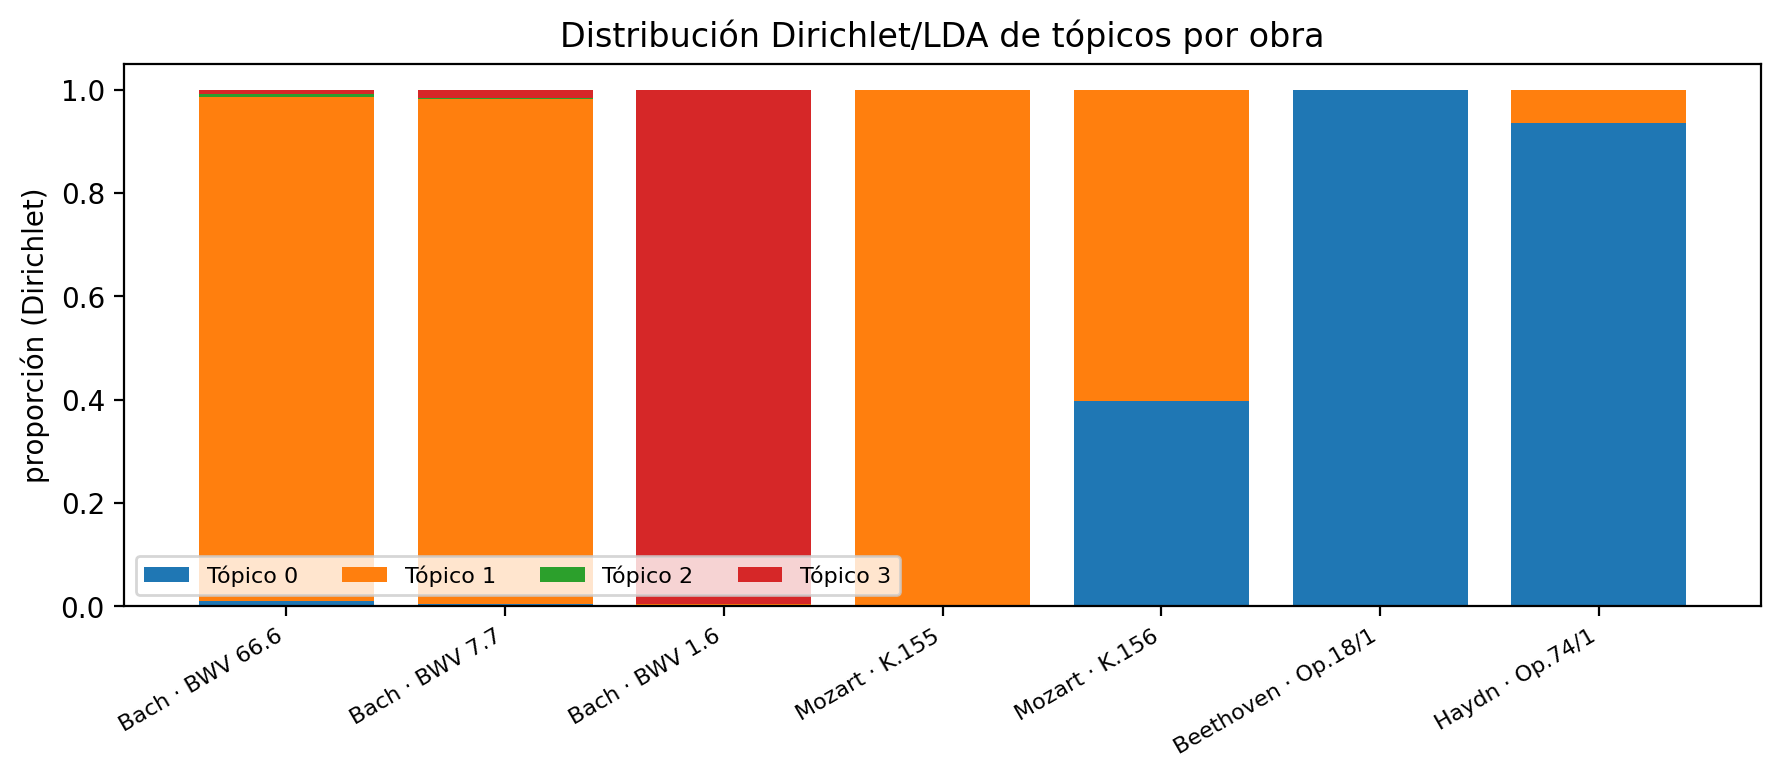

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
def musical_words(score):
    w=[]
    for c in score.chordify().flatten().notes:
        if isinstance(c,chord.Chord):
            w.append('harm_'+'-'.join(map(str,sorted({p.pitchClass for p in c.pitches}))))
    flat=score.parts[0].flatten() if getattr(score,'parts',None) else score.flatten()
    mel=[n.pitch.midi for n in flat.notes if isinstance(n,note.Note)]
    iv=[mel[i+1]-mel[i] for i in range(len(mel)-1)]
    w+= [f'mel_{iv[i]}_{iv[i+1]}' for i in range(len(iv)-1)]
    return ' '.join(w)

docs=[musical_words(scores[n]) for n in names]
vec=CountVectorizer(token_pattern=r'[^ ]+'); Xw=vec.fit_transform(docs)
N_TOPICS=4
lda=LatentDirichletAllocation(N_TOPICS,random_state=42,doc_topic_prior=0.5,
        topic_word_prior=0.1,max_iter=50,learning_method='batch')
doc_topic=lda.fit_transform(Xw)            # mezcla Dirichlet por obra
lda_dist={n:doc_topic[i] for i,n in enumerate(names)}
print('matriz doc-palabra',Xw.shape,'| tópicos',N_TOPICS,'\n')
vocab=np.array(vec.get_feature_names_out())
for t,c in enumerate(lda.components_):
    print(f'Tópico {t}:',', '.join(vocab[c.argsort()[-6:][::-1]]))

# Visualización: distribución de tópicos por obra
fig,ax=plt.subplots(figsize=(9,4)); bottom=np.zeros(len(names))
for t in range(N_TOPICS):
    ax.bar(names,doc_topic[:,t],bottom=bottom,label=f'Tópico {t}'); bottom+=doc_topic[:,t]
ax.set_ylabel('proporción (Dirichlet)'); ax.set_title('Distribución Dirichlet/LDA de tópicos por obra')
ax.legend(fontsize=8,ncol=4); plt.xticks(rotation=30,ha='right',fontsize=8)
plt.tight_layout(); plt.savefig('lda_topics.png',dpi=120); plt.show()

## Comparación de los 3 espacios de representación
La misma pregunta —¿qué obras se parecen?— respondida por tres caminos independientes:
características interpretables, embeddings del **Transformer**, y tópicos **Dirichlet/LDA**.
Que coincidan da robustez; que difieran señala qué captura cada método.

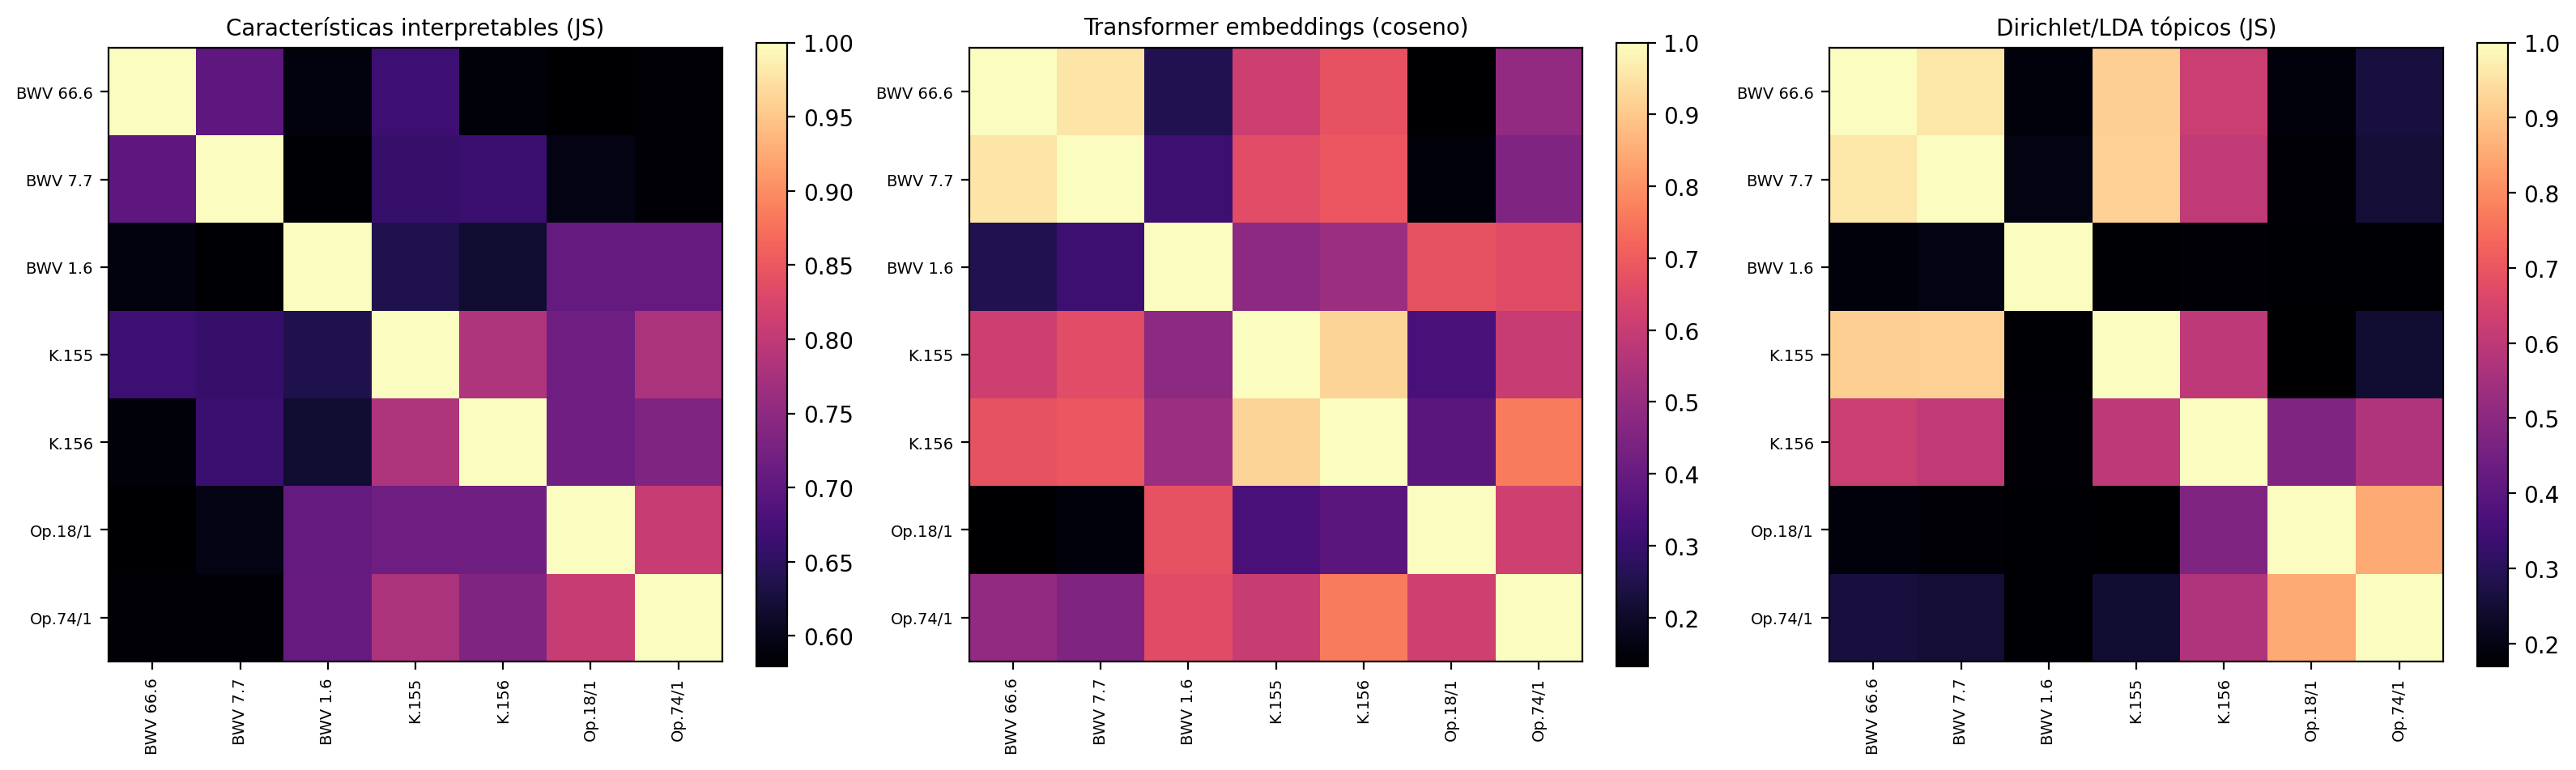

Concordancia (Spearman) entre espacios de representación:
  Características vs Transformer : 0.53
  Características vs Dirichlet   : 0.168
  Transformer vs Dirichlet      : 0.531


In [ ]:
def js(p,q): d=jensenshannon(p+1e-9,q+1e-9); return 1-(0 if np.isnan(d) else d)
def cs(a,b): return 1-cosine(a+1e-9,b+1e-9)
def matrix(fn,rep):
    M=np.array([[fn(rep[a],rep[b]) for b in names] for a in names]); return M
M_feat=matrix(js,feats); M_tr=matrix(cs,tr_emb); M_lda=matrix(js,lda_dist)

fig,axs=plt.subplots(1,3,figsize=(16,5))
for ax,M,ti in zip(axs,[M_feat,M_tr,M_lda],
        ['Características interpretables (JS)','Transformer embeddings (coseno)','Dirichlet/LDA tópicos (JS)']):
    im=ax.imshow(M,cmap='magma',vmin=M.min(),vmax=1)
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels([n.split(' · ')[1] for n in names],rotation=90,fontsize=7)
    ax.set_yticklabels([n.split(' · ')[1] for n in names],fontsize=7)
    ax.set_title(ti,fontsize=10); plt.colorbar(im,ax=ax,fraction=0.046)
plt.tight_layout(); plt.savefig('three_spaces.png',dpi=120); plt.show()

# Concordancia entre métodos (correlación de Spearman de las similitudes)
from scipy.stats import spearmanr
iu=np.triu_indices(len(names),1)
print('Concordancia (Spearman) entre espacios de representación:')
print('  Características vs Transformer :',round(spearmanr(M_feat[iu],M_tr[iu]).correlation,3))
print('  Características vs Dirichlet   :',round(spearmanr(M_feat[iu],M_lda[iu]).correlation,3))
print('  Transformer vs Dirichlet      :',round(spearmanr(M_tr[iu],M_lda[iu]).correlation,3))

## Motivos compartidos resaltados sobre la partitura

4 motivos compartidos entre Bach · BWV 66.6 y Bach · BWV 7.7


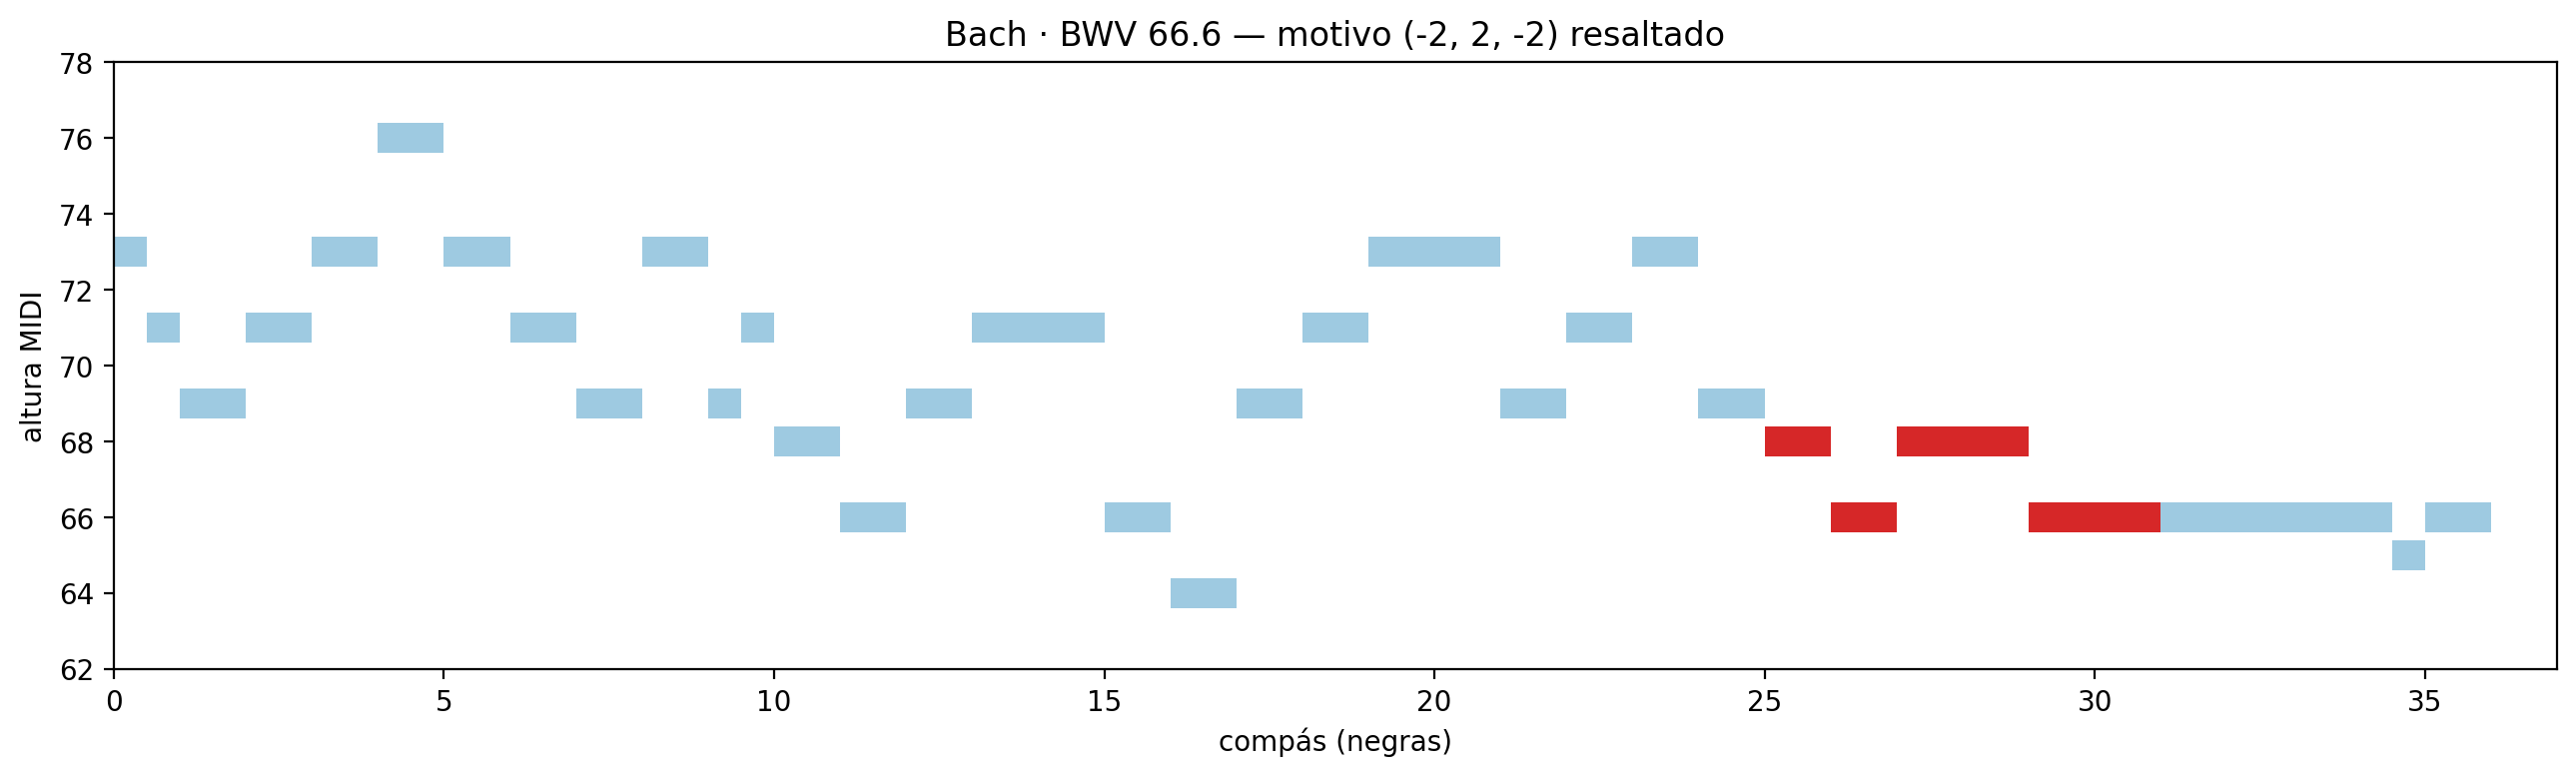

In [ ]:
def ingrams(ev,n=3):
    iv=[ev[i+1]['midi']-ev[i]['midi'] for i in range(len(ev)-1)]; g={}
    for i in range(len(iv)-n+1): g.setdefault(tuple(iv[i:i+n]),[]).append(i)
    return g
def shared(a,b,n=3):
    ga,gb=ingrams(events[a],n),ingrams(events[b],n)
    return {k:dict(A=ga[k],B=gb[k]) for k in set(ga)&set(gb) if k!=tuple([0]*n)}
def roll(ev,starts,n,title,fn):
    hit={k for s in starts for k in range(s,s+n+1)}
    fig,ax=plt.subplots(figsize=(13,4))
    for i,e in enumerate(ev):
        ax.add_patch(Rectangle((e['offset'],e['midi']-.4),max(e['dur'],.2),.8,
                     facecolor='#d62728' if i in hit else '#9ecae1'))
    xs=[e['offset'] for e in ev]; ys=[e['midi'] for e in ev]
    ax.set_xlim(0,max(xs)+2); ax.set_ylim(min(ys)-2,max(ys)+2)
    ax.set_xlabel('compás (negras)'); ax.set_ylabel('altura MIDI'); ax.set_title(title)
    plt.tight_layout(); plt.savefig(fn,dpi=110); plt.show()
A,B=names[0],names[1]; sh=shared(A,B,3)
print(len(sh),'motivos compartidos entre',A,'y',B)
if sh:
    mo,lo=max(sh.items(),key=lambda kv:sum(abs(x) for x in kv[0]))
    roll(events[A],lo['A'],3,f'{A} — motivo {mo} resaltado','score_highlight.png')

## 12 · Red de influencias (sensible a cronología)

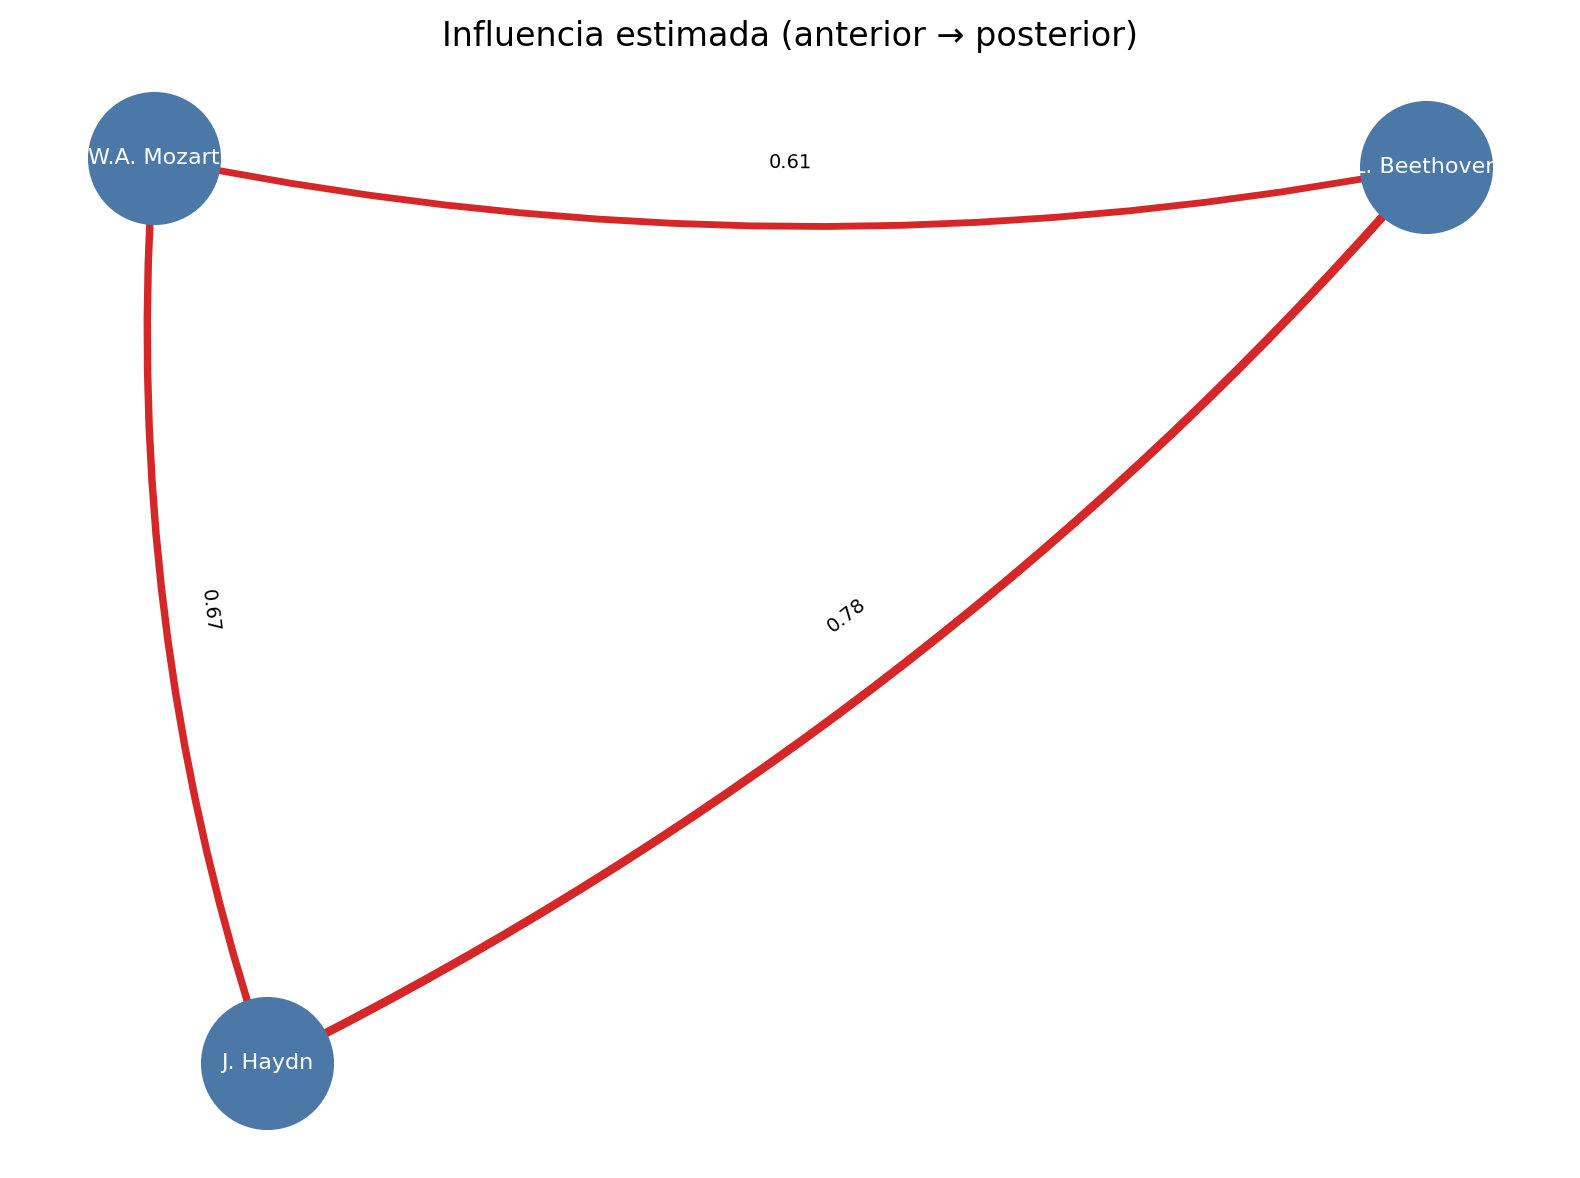

In [ ]:
import networkx as nx
def infl(s,d):
    ys,yd=CATALOG[s]['year'],CATALOG[d]['year']
    if ys>=yd: return 0.0
    return round(js(feats[s],feats[d])*(0.5+0.5*np.exp(-abs(yd-ys)/80)),3)
CG=nx.DiGraph()
for a in names:
    for b in names:
        if CATALOG[a]['composer']!=CATALOG[b]['composer']:
            w=infl(a,b)
            if w>0.55:
                u,v=CATALOG[a]['composer'],CATALOG[b]['composer']
                if CG.has_edge(u,v): CG[u][v]['weight']=(CG[u][v]['weight']+w)/2
                else: CG.add_edge(u,v,weight=w)
fig,ax=plt.subplots(figsize=(8,6)); pos=nx.spring_layout(CG,seed=42,k=1.5)
nx.draw_networkx_nodes(CG,pos,node_size=2200,node_color='#4c78a8')
nx.draw_networkx_labels(CG,pos,font_size=8,font_color='white')
nx.draw_networkx_edges(CG,pos,width=[CG[u][v]['weight']*4 for u,v in CG.edges()],
        edge_color='#d62728',arrowsize=20,connectionstyle='arc3,rad=0.1')
nx.draw_networkx_edge_labels(CG,pos,{(u,v):f"{d['weight']:.2f}" for u,v,d in CG.edges(data=True)},font_size=7)
ax.set_title('Influencia estimada (anterior → posterior)'); ax.axis('off')
plt.tight_layout(); plt.savefig('influence_network.png',dpi=120); plt.show()

## 14 · Informe y exportación

In [ ]:
rows=[]
for i in range(len(names)):
    for j in range(i+1,len(names)):
        rows.append(dict(A=names[i],B=names[j],
            sim_caracteristicas=round(M_feat[i,j],3),
            sim_transformer=round(M_tr[i,j],3),
            sim_dirichlet=round(M_lda[i,j],3)))
df=pd.DataFrame(rows).sort_values('sim_transformer',ascending=False)
df.to_csv('similarity_report.csv',index=False)
import IPython.display as d; d.display(df.head(8))
print('Figuras: lda_topics.png, three_spaces.png, score_highlight.png, influence_network.png')

,A,B,sim_caracteristicas,sim_transformer,sim_dirichlet
0,Bach · BWV 66.6,Bach · BWV 7.7,0.700,0.954,0.958
15,Mozart · K.155,Mozart · K.156,0.783,0.923,0.598
19,Mozart · K.156,Haydn · Op.74/1,0.734,0.762,0.574
8,Bach · BWV 7.7,Mozart · K.156,0.663,0.690,0.606
13,Bach · BWV 1.6,Beethoven · Op.18/1,0.707,0.680,0.173
3,Bach · BWV 66.6,Mozart · K.156,0.586,0.679,0.624
7,Bach · BWV 7.7,Mozart · K.155,0.660,0.661,0.922
14,Bach · BWV 1.6,Haydn · Op.74/1,0.708,0.659,0.175


Figuras: lda_topics.png, three_spaces.png, score_highlight.png, influence_network.png


## Qué es real aquí y qué falta para nivel publicación
**Implementado y entrenado en este notebook:** Transformer encoder con self-attention
(objetivo MLM, *loss* decreciente, embeddings extraídos) y LDA/Dirichlet (tópicos
interpretables, distribución por obra). Tres espacios de representación comparados con
concordancia de Spearman.

**Para llevarlo a investigación seria:** (1) entrenar el Transformer sobre un corpus grande
(miles de obras, p.ej. `miditok`+MAESTRO/ASAP) o cargar un *checkpoint* preentrenado —
con 8 obras es prueba de concepto; (2) en LDA, validar el nº de tópicos con perplejidad y
coherencia, y considerar el **Proceso de Dirichlet Jerárquico (HDP)** para no fijar K a mano;
(3) validar toda similitud contra juicios de expertos con intervalos de confianza. La
arquitectura modular permite escalar cada pieza sin tocar el resto.
